# Generative Models: VAEs, GANs & Diffusion Models

Generative models learn the underlying data distribution $p(x)$ to generate new samples.

## 1. Variational Autoencoders (VAE)

Kingma & Welling (2013). A probabilistic encoder-decoder framework.

### Objective: Evidence Lower Bound (ELBO)

We want to maximize $\log p(x)$. Using Jensen's inequality:

$$\log p(x) \geq \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$$

$$\mathcal{L}_{VAE} = \underbrace{\mathbb{E}_{q(z|x)}[\log p(x|z)]}_{\text{Reconstruction}} - \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{Regularization}}$$

**Encoder** $q_\phi(z|x)$: approximates posterior $p(z|x)$. Outputs $\mu, \sigma$ of Gaussian.
**Decoder** $p_\theta(x|z)$: reconstructs $x$ from latent $z$.
**Prior** $p(z) = \mathcal{N}(0, I)$.

### KL Divergence (closed form for Gaussians)
$$D_{KL}(\mathcal{N}(\mu, \sigma^2) \| \mathcal{N}(0,1)) = -\frac{1}{2}\sum_j\left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

### Reparameterization Trick
Sample $z = \mu + \epsilon \sigma$ where $\epsilon \sim \mathcal{N}(0, I)$.
This makes sampling differentiable w.r.t. $\mu$ and $\sigma$.

### $\beta$-VAE
$$\mathcal{L} = \mathbb{E}[\log p(x|z)] - \beta \cdot D_{KL}(q(z|x) \| p(z))$$
$\beta > 1$ encourages **disentangled** representations.

## 2. Generative Adversarial Networks (GAN)

Goodfellow et al. (2014). Two networks compete:
- **Generator** $G$: maps noise $z \sim p_z$ → fake data
- **Discriminator** $D$: classifies real vs. fake

### Minimax Game
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

**Optimal discriminator**: $D^*(x) = \frac{p_{data}(x)}{p_{data}(x) + p_g(x)}$

**At optimality**: $p_g = p_{data}$, and $D^*(x) = \frac{1}{2}$ everywhere.

### Wasserstein GAN (WGAN)
Uses **Earth Mover (Wasserstein-1) distance** instead of Jensen-Shannon divergence:
$$W(P_r, P_g) = \sup_{\|f\|_L \leq 1} \mathbb{E}_{x \sim P_r}[f(x)] - \mathbb{E}_{x \sim P_g}[f(x)]$$

$$\mathcal{L}_{WGAN} = \mathbb{E}_{x \sim P_r}[D(x)] - \mathbb{E}_{z}[D(G(z))]$$

Critic (not discriminator) must be Lipschitz continuous.
**WGAN-GP**: enforces Lipschitz via gradient penalty:
$$\mathcal{L}_{GP} = \lambda \mathbb{E}_{\hat{x}}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$

## 3. Diffusion Models (DDPM)

Ho et al. (2020). Learn to reverse a gradual noising process.

### Forward Process (Fixed Markov Chain)
Gradually add Gaussian noise over $T$ steps:
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t} x_{t-1}, \beta_t I)$$

**Closed form** (nice property):
$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1-\bar{\alpha}_t) I)$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.

So: $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$, $\epsilon \sim \mathcal{N}(0,I)$

### Reverse Process (Learned)
$$p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

### Training Objective (simplified)
Train a U-Net $\epsilon_\theta$ to predict the noise:
$$\mathcal{L}_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\|\epsilon - \epsilon_\theta(\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon, t)\|^2\right]$$

### DDIM (Song et al., 2020)
Deterministic sampling can generate in fewer steps (50 vs 1000) without quality loss.

## 4. Flow-based Models (Normalizing Flows)

Learn invertible transformation $f: x \rightarrow z$:
$$\log p(x) = \log p(z) + \log \left|\det \frac{\partial f}{\partial x}\right|$$

Examples: RealNVP, Glow, MAF.

## 5. Energy-Based Models (EBM)
$$p_\theta(x) = \frac{e^{-E_\theta(x)}}{Z_\theta}$$
Training via contrastive divergence or MCMC.

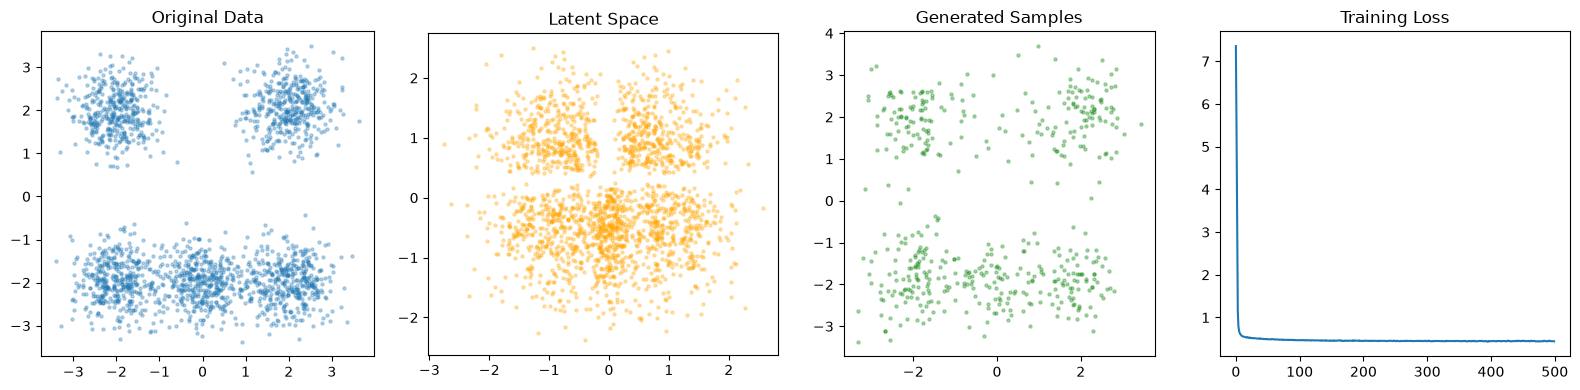

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# VAE on 2D toy data
# ============================================================

class Encoder(nn.Module):
    def __init__(self, in_dim, hidden, latent):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU())
        self.mu_layer  = nn.Linear(hidden, latent)
        self.log_var_layer = nn.Linear(hidden, latent)

    def forward(self, x):
        h = self.net(x)
        return self.mu_layer(h), self.log_var_layer(h)

class Decoder(nn.Module):
    def __init__(self, latent, hidden, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, out_dim))
    def forward(self, z): return self.net(z)

class VAE(nn.Module):
    def __init__(self, in_dim=2, hidden=64, latent=2):
        super().__init__()
        self.encoder = Encoder(in_dim, hidden, latent)
        self.decoder = Decoder(latent, hidden, in_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std  # reparameterization trick

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

    def loss(self, x, x_recon, mu, log_var, beta=1.0):
        recon_loss = F.mse_loss(x_recon, x, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        return recon_loss + beta * kl_loss, recon_loss, kl_loss

# Generate 2D mixture of Gaussians
def make_mog_data(n=2000):
    centers = [(2,2),(-2,2),(0,-2),(2,-2),(-2,-2)]
    X = np.vstack([np.random.randn(n//5, 2)*0.5 + c for c in centers])
    return torch.FloatTensor(X)

data = make_mog_data(2000)
vae  = VAE(in_dim=2, hidden=64, latent=2)
opt  = optim.Adam(vae.parameters(), lr=1e-3)

losses = []
for epoch in range(500):
    perm = torch.randperm(len(data))
    epoch_loss = 0
    for i in range(0, len(data), 128):
        batch = data[perm[i:i+128]]
        x_r, mu, lv = vae(batch)
        loss, _, _ = vae.loss(batch, x_r, mu, lv, beta=0.1)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(data))

# Visualize
with torch.no_grad():
    z_samples = torch.randn(500, 2)
    gen = vae.decoder(z_samples).numpy()
    mu, _ = vae.encoder(data)
    latent = mu.numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].scatter(*data.numpy().T, alpha=0.3, s=5); axes[0].set_title('Original Data')
axes[1].scatter(*latent.T, alpha=0.3, s=5, c='orange'); axes[1].set_title('Latent Space')
axes[2].scatter(*gen.T, alpha=0.3, s=5, c='green'); axes[2].set_title('Generated Samples')
axes[3].plot(losses); axes[3].set_title('Training Loss')
for ax in axes[:3]: ax.set_aspect('equal')
plt.tight_layout(); plt.show()

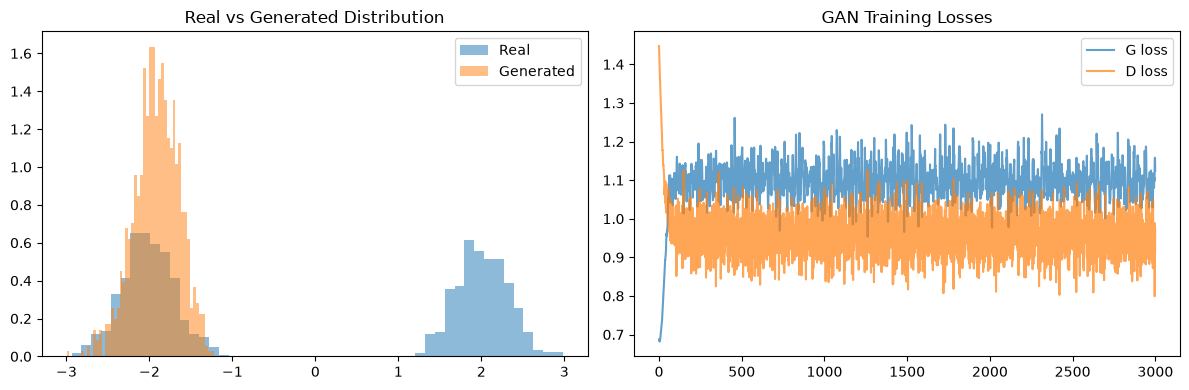


--- Diffusion Forward Process ---
t=   0: x_t=1.0334, signal=0.9999, noise=0.0001
t= 100: x_t=0.6526, signal=0.8951, noise=0.1049
t= 250: x_t=0.4364, signal=0.5214, noise=0.4786
t= 500: x_t=1.1688, signal=0.0778, noise=0.9222
t= 750: x_t=-0.4014, signal=0.0033, noise=0.9967
t= 999: x_t=0.3534, signal=0.0000, noise=1.0000


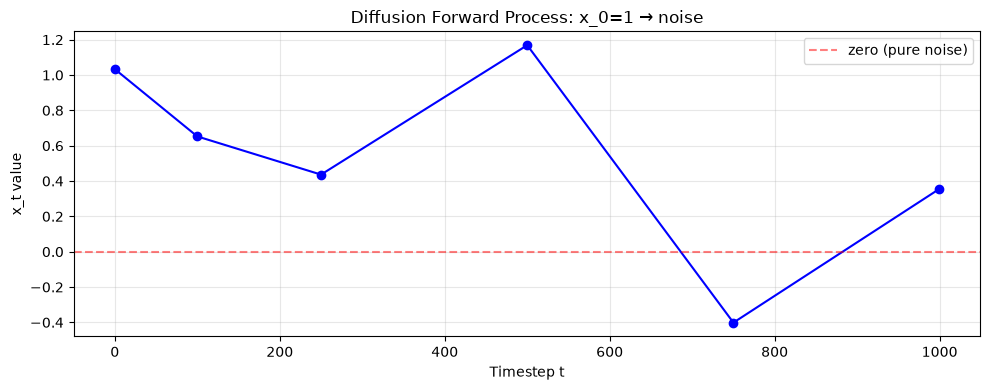

In [2]:
# ============================================================
# Simple GAN on 1D data
# ============================================================

class Generator(nn.Module):
    def __init__(self, z_dim=16, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128),   nn.LeakyReLU(0.2),
            nn.Linear(128, out_dim)
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128),    nn.LeakyReLU(0.2),
            nn.Linear(128, 1),      nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

Z_DIM = 16
G = Generator(Z_DIM, 1)
D = Discriminator(1)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# Real data: bimodal Gaussian
def sample_real(n): return torch.FloatTensor(np.random.randn(n,1)*0.3 + np.random.choice([-2,2], n).reshape(-1,1))

g_losses, d_losses = [], []
for step in range(3000):
    batch = 128
    real = sample_real(batch)
    z    = torch.randn(batch, Z_DIM)
    fake = G(z).detach()

    # Train D
    d_real = D(real)
    d_fake = D(fake)
    loss_D = criterion(d_real, torch.ones_like(d_real)) + criterion(d_fake, torch.zeros_like(d_fake))
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()

    # Train G
    z = torch.randn(batch, Z_DIM)
    fake = G(z)
    loss_G = criterion(D(fake), torch.ones_like(D(fake)))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    g_losses.append(loss_G.item())
    d_losses.append(loss_D.item())

with torch.no_grad():
    gen_samples = G(torch.randn(1000, Z_DIM)).numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
real_np = sample_real(1000).numpy().flatten()
axes[0].hist(real_np, bins=50, alpha=0.5, label='Real', density=True)
axes[0].hist(gen_samples, bins=50, alpha=0.5, label='Generated', density=True)
axes[0].legend(); axes[0].set_title('Real vs Generated Distribution')
axes[1].plot(g_losses, label='G loss', alpha=0.7)
axes[1].plot(d_losses, label='D loss', alpha=0.7)
axes[1].legend(); axes[1].set_title('GAN Training Losses')
plt.tight_layout(); plt.show()

# Diffusion forward process visualization
print('\n--- Diffusion Forward Process ---')
T = 1000
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

x0 = torch.tensor([[1.0]])  # starting point
fig, ax = plt.subplots(figsize=(10, 4))
timesteps = [0, 100, 250, 500, 750, 999]
noisy = []
for t in timesteps:
    eps = torch.randn_like(x0)
    xt = alpha_bars[t].sqrt() * x0 + (1 - alpha_bars[t]).sqrt() * eps
    noisy.append(xt.item())
    print(f't={t:4d}: x_t={xt.item():.4f}, signal={alpha_bars[t].item():.4f}, noise={(1-alpha_bars[t].item()):.4f}')

ax.plot(timesteps, noisy, 'bo-')
ax.axhline(0, color='r', linestyle='--', alpha=0.5, label='zero (pure noise)')
ax.set_xlabel('Timestep t'); ax.set_ylabel('x_t value')
ax.set_title('Diffusion Forward Process: x_0=1 → noise')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Additional Learning Resources

### Key Papers
- **VAE** (Kingma & Welling, 2013): https://arxiv.org/abs/1312.6114
- **β-VAE** (Higgins et al., 2017): https://openreview.net/forum?id=Sy2fchgxl
- **GAN** (Goodfellow et al., 2014): https://arxiv.org/abs/1406.2661
- **DCGAN** (Radford et al., 2015): https://arxiv.org/abs/1511.06434
- **WGAN** (Arjovsky et al., 2017): https://arxiv.org/abs/1701.07875
- **WGAN-GP** (Gulrajani et al., 2017): https://arxiv.org/abs/1704.00028
- **StyleGAN2** (Karras et al., 2020): https://arxiv.org/abs/1912.04958
- **DDPM** (Ho et al., 2020): https://arxiv.org/abs/2006.11239
- **DDIM** (Song et al., 2020): https://arxiv.org/abs/2010.02502
- **Stable Diffusion / LDM** (Rombach et al., 2022): https://arxiv.org/abs/2112.10752
- **Score Matching** (Song & Ermon, 2019): https://arxiv.org/abs/1907.05600

### Blogs & Tutorials
- **What are Diffusion Models?** Lil'Log: https://lilianweng.github.io/posts/2021-07-11-diffusion-models/
- **From Autoencoder to Beta-VAE** Lil'Log: https://lilianweng.github.io/posts/2018-08-12-vae/
- **GANs overview** Lil'Log: https://lilianweng.github.io/posts/2017-08-20-gan/
- **The Illustrated Stable Diffusion** Jay Alammar: https://jalammar.github.io/illustrated-stable-diffusion/
- **Hugging Face Diffusers**: https://huggingface.co/docs/diffusers